# Surrogate Modeling for Sensitivity Analysis
## AUC Prediction for Polarization Curve Regions

Running sensitivity analysis (e.g., Sobol indices) directly on the AlphaPEM simulator is computationally expensive. Each simulation run requires significant time, and evaluating global sensitivities over thousands of configurations is not feasible in practice.

To overcome this, we decided to train a surrogate model (SM) using XGBoost that can approximate the AlphaPEM outputs — specifically, the integrated voltage (AUC) in different regions of the polarization curve. If the surrogate generalizes well, then it can be used in place of AlphaPEM to compute sensitivities more efficiently.

The goal is not to interpret the model itself, but to enable efficient approximation of Sobol or Shapley-based global sensitivity indices using a fast and accurate surrogate.


In [38]:
import os
import sys
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

# Scikit-learn
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from SALib.sample import saltelli
from SALib.analyze import sobol
from SALib.sample import sobol as sobol_sampler
from SALib.analyze import sobol as sobol_analyzer
import warnings
import shap

# Custom modules
sys.path.append("../external/AlphaPEM")
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters
from src.validity.validity_criteria import validate_polarization_curves

### Region definitions

The polarization curve is split into three regions, based on current density:

In [3]:
REGIONS = {
    "activation": (0.0, 0.4),
    "ohmic": (0.4, 1.6),
    "mass_transport": (1.6, np.inf),
}

## Utils definition: Useful functions

### Compute AUC for a Region

For each configuration, we want to compute a discrete integral (using trapezoidal rule) of the voltage values over the selected current range.

In [4]:
def compute_region_auc(row, ifc_cols, ucell_cols, region_bounds):
    ifcs = row[ifc_cols].values
    volts = row[ucell_cols].values
    mask = (ifcs >= region_bounds[0]) & (ifcs < region_bounds[1])
    return np.trapezoid(volts[mask], ifcs[mask]) if np.any(mask) else np.nan

### Nested Cross-Validation for One Region

The function below performs nested cross-validation for a selected region. It computes the AUC per configuration, trains an XGBoost model using only the input parameters (no ifc), and evaluates performance using outer CV.

In [13]:
def train_auc_model_for_region(valid_data, region_name, input_cols, param_grid=None):
    assert region_name in REGIONS, f"Unknown region: {region_name}"
    region_bounds = REGIONS[region_name]
    print(f"[INFO] Starting nested CV for region: '{region_name}' in range {region_bounds}")

    # Identify relevant columns
    ifc_cols = [col for col in valid_data.columns if col.startswith("ifc_")]
    ucell_cols = [col for col in valid_data.columns if col.startswith("Ucell_")]
    print(f"[INFO] Identified {len(ifc_cols)} current density columns and {len(ucell_cols)} voltage columns.")

    # Compute region-specific AUC
    target_name = f"AUC_{region_name}"
    print(f"[INFO] Computing AUC target for region: {region_name}")
    valid_data[target_name] = valid_data.apply(
        compute_region_auc, axis=1, args=(ifc_cols, ucell_cols, region_bounds)
    )
    n_before = len(valid_data)
    valid_data = valid_data.dropna(subset=[target_name])
    print(f"[INFO] Dropped {n_before - len(valid_data)} samples with no valid AUC in this region. Remaining: {len(valid_data)}")

    # Prepare input and output
    X = valid_data[input_cols]
    y = valid_data[target_name]
    groups = valid_data["config_id"]
    print(f"[INFO] Input shape: {X.shape}. Target shape: {y.shape}")

    # Default param grid (expanded)
    if param_grid is None:
        param_grid = {
            "n_estimators": [300, 500, 700],
            "max_depth": [6, 8, 10],
            "learning_rate": [0.01, 0.05],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }

    total_combinations = (
        len(param_grid["n_estimators"]) *
        len(param_grid["max_depth"]) *
        len(param_grid["learning_rate"]) *
        len(param_grid["subsample"]) *
        len(param_grid["colsample_bytree"])
    )
    print(f"[INFO] Defined hyperparameter grid with {total_combinations} combinations")

    model = xgb.XGBRegressor(random_state=42, n_jobs=-1)
    outer_cv = GroupKFold(n_splits=5)
    scores = {"mae": [], "r2": [], "rmse": []}

    for i, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups)):
        print(f"\n[INFO] Starting outer fold {i+1}/5")
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

        inner_cv = GroupKFold(n_splits=3)
        print("[INFO] Performing inner grid search (3-fold CV)...")
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            scoring="neg_mean_absolute_error",
            cv=inner_cv.split(X_train, y_train, groups.iloc[train_idx]),
            n_jobs=-1,
            verbose=0
        )
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        print(f"[INFO] Best hyperparameters for fold {i+1}: {grid.best_params_}")

        y_pred = best_model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        rmse = mean_squared_error(y_true=y_test, y_pred=y_pred)

        scores["mae"].append(mae)
        scores["r2"].append(r2)
        scores["rmse"].append(rmse)

        print(f"[INFO] Fold {i+1} results — MAE={mae:.4f}, R²={r2:.4f}, RMSE={rmse:.4f}")

    print("\n[INFO] Cross-Validation Summary:")
    for metric in scores:
        print(f"  Mean {metric.upper()}: {np.mean(scores[metric]):.4f} ± {np.std(scores[metric]):.4f}")

    print(f"[INFO] Finished nested CV for region: '{region_name}'")
    return best_model, scores

In [6]:
def plot_shap_bar(shap_df, top_n=13):
    plt.figure(figsize=(8, 5))
    plt.barh(shap_df["feature"][:top_n][::-1], shap_df["mean_abs_shap"][:top_n][::-1])
    plt.xlabel("Mean(|SHAP value|)")
    plt.title("SHAP Feature Importance")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [8]:
def compute_shap_importance(model, df, region_name, input_cols, sample_frac=1.0, random_state=42, verbose=True):
    """
    Computes SHAP feature importance for a trained XGBoost model on AUC prediction.

    Parameters
    ----------
    model : xgboost.XGBRegressor
        Trained model.
    df : pd.DataFrame
        Full validated dataset, must include config_id and AUC_<region_name> column.
    region_name : str
        Name of the region (e.g., "activation", "ohmic", "mass_transport").
    input_cols : list
        List of input feature names (13 features).
    sample_frac : float, optional
        Fraction of data to sample for SHAP computation (default 1.0).
    random_state : int, optional
        Random seed for reproducibility.
    verbose : bool, optional
        Whether to print progress info.

    Returns
    -------
    pd.DataFrame
        SHAP feature importance ranking with columns ['feature', 'mean_abs_shap'].
    """
    target_col = f"AUC_{region_name}"

    if target_col not in df.columns:
        raise ValueError(f"[ERROR] Column '{target_col}' not found in the dataframe.")

    # Filter rows with non-NaN AUC
    df_region = df.dropna(subset=[target_col]).copy()
    X_full = df_region[input_cols]

    if sample_frac < 1.0:
        X_sample = X_full.sample(frac=sample_frac, random_state=random_state)
        if verbose:
            print(f"[INFO] Using a sample of {len(X_sample)} rows from {len(X_full)} total rows for SHAP.")
    else:
        X_sample = X_full
        if verbose:
            print(f"[INFO] Using full dataset ({len(X_sample)} rows) for SHAP.")

    if verbose:
        print("[INFO] Creating SHAP TreeExplainer...")
    explainer = shap.Explainer(model)

    if verbose:
        print("[INFO] Computing SHAP values...")
    shap_values = explainer(X_sample)

    if verbose:
        print("[INFO] Aggregating mean absolute SHAP values per feature...")
    mean_abs_shap = pd.DataFrame({
        "feature": X_sample.columns,
        "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
    }).sort_values(by="mean_abs_shap", ascending=False)

    return mean_abs_shap

In [9]:
def save_model_results(model, region_name, input_cols, df, cv_scores, shap_df, save_dir="../results/xgboost"):
    """
    Saves the trained model, metrics, config, and SHAP ranking to disk.

    Parameters
    ----------
    model : xgb.XGBRegressor
        Trained surrogate model.
    region_name : str
        Name of the region (e.g., "ohmic").
    input_cols : list of str
        List of input feature names used in training.
    df : pd.DataFrame
        The full dataset (must include config_id and AUC_<region>).
    cv_scores : dict
        Dictionary with CV metrics (keys: 'mae', 'r2', 'rmse').
    shap_df : pd.DataFrame
        SHAP feature importance rankings (columns: ['feature', 'mean_abs_shap']).
    save_dir : str
        Folder to save model and outputs.
    """
    os.makedirs(save_dir, exist_ok=True)

    # Define base filename
    base = os.path.join(save_dir, f"xgb_{region_name}")

    # 1. Save model
    model_path = f"{base}_model.pkl"
    joblib.dump(model, model_path)
    print(f"[INFO] Saved model to {model_path}")

    # 2. Save metrics and config
    metrics = {
        "region": region_name,
        "features": input_cols,
        "cv_mean_mae": float(np.mean(cv_scores["mae"])),
        "cv_std_mae": float(np.std(cv_scores["mae"])),
        "cv_mean_r2": float(np.mean(cv_scores["r2"])),
        "cv_std_r2": float(np.std(cv_scores["r2"])),
        "cv_mean_rmse": float(np.mean(cv_scores["rmse"])),
        "cv_std_rmse": float(np.std(cv_scores["rmse"]))
    }
    metrics_path = f"{base}_metrics.json"
    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=4)
    print(f"[INFO] Saved metrics to {metrics_path}")

    # 3. Save SHAP ranking
    shap_path = f"{base}_shap.csv"
    shap_df.to_csv(shap_path, index=False)
    print(f"[INFO] Saved SHAP ranking to {shap_path}")

## Processing: Ohmic region

### Step 1: Load valid data

Let's begin by loading the validated polarization curve data. Only rows labeled as "valid" are retained, since invalid or failed simulations are not meaningful for sensitivity analysis.

In [10]:
data = pd.read_pickle("../sampling_test/validated_final_df.pkl")
valid_data = data[data["classification"].isin(["valid"])].copy()
print("There are", len(valid_data), "valid polarization curves available.")

valid_data["config_id"] = valid_data.index

ifc_columns = [col for col in data.columns if col.startswith("ifc_")]
ucell_columns = [col for col in data.columns if col.startswith("Ucell_")]

INPUT_COLUMNS = [
    'Tfc', 'Pa_des', 'Sc', 'Phi_c_des', 'epsilon_gdl', 'tau',
    'epsilon_mc', 'epsilon_c', 'e', 'Re', 'i0_c_ref', 'kappa_co', 'kappa_c'
]

There are 27708 valid polarization curves available.


In [11]:
REGIONS = {
    "activation": (0.0, 0.4),
    "ohmic": (0.4, 1.6),
    "mass_transport": (1.6, np.inf),
}

### Step 2: Train the Surrogate Model
Let's now train a surrogate model to predict the AUC in the Ohmic region using the 13 input features. This involves nested cross-validation with a grid search over XGBoost hyperparameters.

In [14]:
model_ohmic, metrics_ohmic = train_auc_model_for_region(
    valid_data, region_name="ohmic", input_cols=INPUT_COLUMNS
)

[INFO] Starting nested CV for region: 'ohmic' in range (0.4, 1.6)
[INFO] Identified 31 current density columns and 31 voltage columns.
[INFO] Computing AUC target for region: ohmic
[INFO] Dropped 0 samples with no valid AUC in this region. Remaining: 27708
[INFO] Input shape: (27708, 13). Target shape: (27708,)
[INFO] Defined hyperparameter grid with 72 combinations

[INFO] Starting outer fold 1/5
[INFO] Performing inner grid search (3-fold CV)...
[INFO] Best hyperparameters for fold 1: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 700, 'subsample': 1.0}
[INFO] Fold 1 results — MAE=0.0637, R²=0.6281, RMSE=0.0311

[INFO] Starting outer fold 2/5
[INFO] Performing inner grid search (3-fold CV)...
[INFO] Best hyperparameters for fold 2: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 700, 'subsample': 1.0}
[INFO] Fold 2 results — MAE=0.0631, R²=0.6152, RMSE=0.0337

[INFO] Starting outer fold 3/5
[INFO] Performing inner g

The following output shows the best hyperparameters selected in each fold and the resulting performance metrics (MAE, R², RMSE). These help assess the model's reliability before using it for sensitivity analysis.

In [15]:
print("Metrics for the Ohmic region")
print(metrics_ohmic)

Metrics for the Ohmic region
{'mae': [0.06367137320770964, 0.06305313096702625, 0.06396069853274385, 0.06304316458142438, 0.06233810898735288], 'r2': [0.6280728070919235, 0.6152084545466789, 0.6566303068889293, 0.6498372434847683, 0.6516961284506728], 'rmse': [0.031141103628472812, 0.033727760321341636, 0.03124354986210997, 0.03223506627785859, 0.03140689628222166]}


### Step 3: SHAP-Based Sensitivity Analysis

To understand which input features most influence the AUC predictions, we can use SHAP (SHapley Additive exPlanations) to compute feature importances from the trained XGBoost model. This gives a ranked list of parameters by their impact on model output.

Computing SHAP values on the full dataset can be computationally expensive. We can instead use a 30% subsample to speed up analysis while still capturing the main feature interactions. 

In [76]:
shap_df_ohmic = compute_shap_importance(
    model=model_ohmic,
    df=valid_data,
    region_name="ohmic",
    input_cols=INPUT_COLUMNS,
    sample_frac=1
)

[INFO] Using full dataset (27708 rows) for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] Aggregating mean absolute SHAP values per feature...


In [77]:
shap_df_ohmic

,feature,mean_abs_shap
5,tau,0.061598
10,i0_c_ref,0.054816
1,Pa_des,0.042725
0,Tfc,0.041320
6,epsilon_mc,0.033024
12,kappa_c,0.032289
9,Re,0.019170
3,Phi_c_des,0.015038
11,kappa_co,0.011422
2,Sc,0.010178


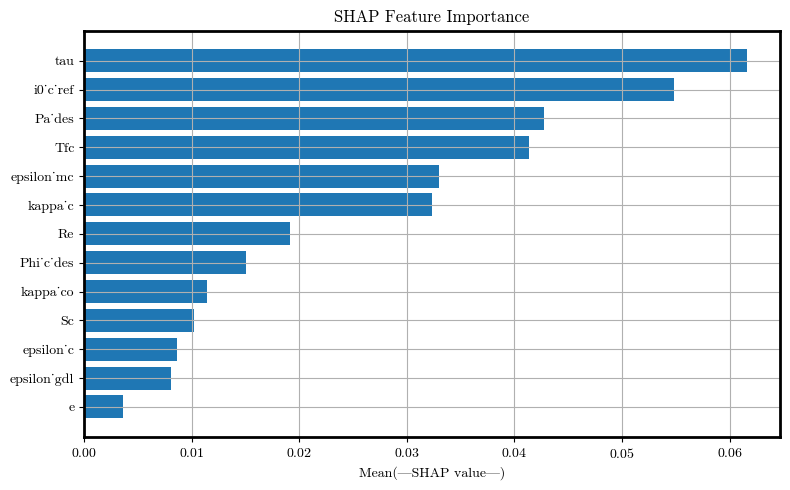

In [79]:
plot_shap_bar(shap_df_ohmic)

### Step 4: Save Model, Metrics, and SHAP Ranking

Once the surrogate model has been trained and validated, we save all relevant outputs for future use. This includes:

- The trained XGBoost model (`.pkl`)
- A JSON file with cross-validation metrics (MAE, R², RMSE + std)
- A CSV file with the SHAP-based feature importance ranking

These are saved to `../results/xgboost/` under filenames specific to the region (e.g., `xgb_ohmic_model.pkl`, `xgb_ohmic_metrics.json`, `xgb_ohmic_shap.csv`).

This allows us to reuse the model for sensitivity analysis and preserve a complete record of how it was trained and evaluated.

In [80]:
save_model_results(
    model=model_ohmic,
    region_name="ohmic",
    input_cols=INPUT_COLUMNS,
    df=valid_data,
    cv_scores=metrics_ohmic,
    shap_df=shap_df_ohmic
)

[INFO] Saved model to ../results/xgboost\xgb_ohmic_model.pkl
[INFO] Saved metrics to ../results/xgboost\xgb_ohmic_metrics.json
[INFO] Saved SHAP ranking to ../results/xgboost\xgb_ohmic_shap.csv


Idea: Repeat SHAP with Different random samples

If the top features stay the same, that’s a good sign of robustness. If rankings jump around, then your SHAP estimates are too sensitive to sampling.

Using seed 42
[INFO] Using a sample of 8312 rows from 27708 total rows for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] Aggregating mean absolute SHAP values per feature...
       feature  mean_abs_shap
5          tau       0.061918
10    i0_c_ref       0.054608
1       Pa_des       0.042722
0          Tfc       0.041632
6   epsilon_mc       0.033019
12     kappa_c       0.032288


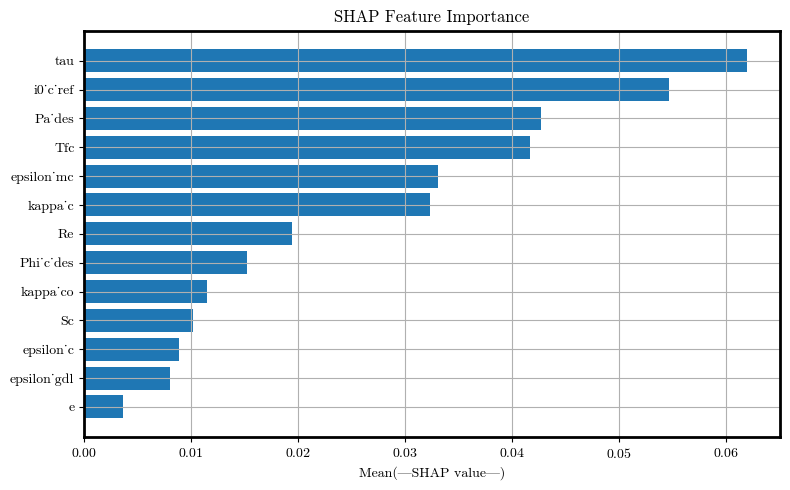

Using seed 1
[INFO] Using a sample of 8312 rows from 27708 total rows for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] Aggregating mean absolute SHAP values per feature...
       feature  mean_abs_shap
5          tau       0.061480
10    i0_c_ref       0.054167
1       Pa_des       0.042762
0          Tfc       0.041414
6   epsilon_mc       0.032363
12     kappa_c       0.031785


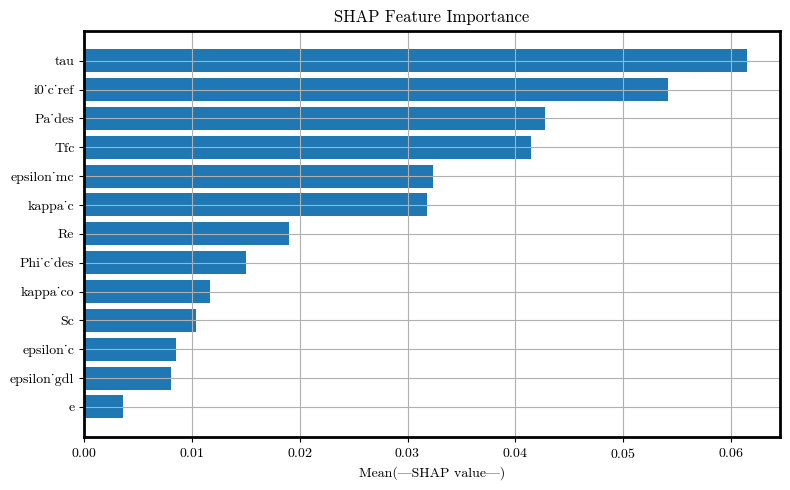

Using seed 7
[INFO] Using a sample of 8312 rows from 27708 total rows for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] Aggregating mean absolute SHAP values per feature...
       feature  mean_abs_shap
5          tau       0.062171
10    i0_c_ref       0.055972
1       Pa_des       0.042578
0          Tfc       0.041453
6   epsilon_mc       0.033145
12     kappa_c       0.032150


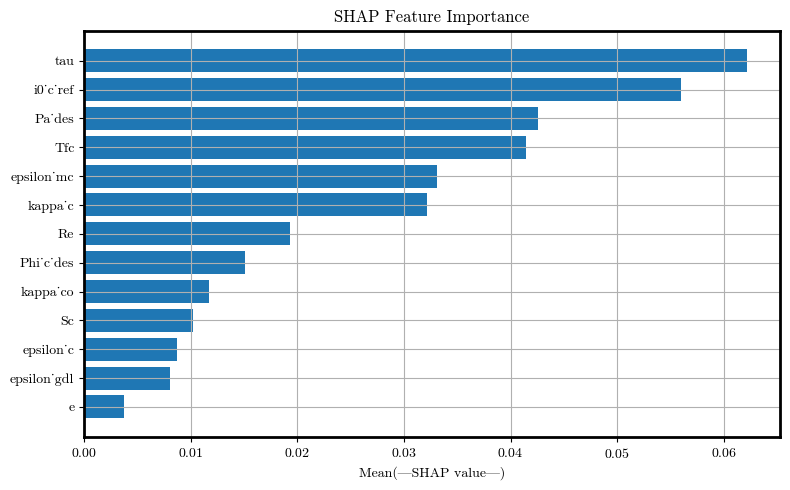

Using seed 101
[INFO] Using a sample of 8312 rows from 27708 total rows for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] Aggregating mean absolute SHAP values per feature...
       feature  mean_abs_shap
5          tau       0.061725
10    i0_c_ref       0.055578
1       Pa_des       0.043285
0          Tfc       0.041434
6   epsilon_mc       0.032721
12     kappa_c       0.032277


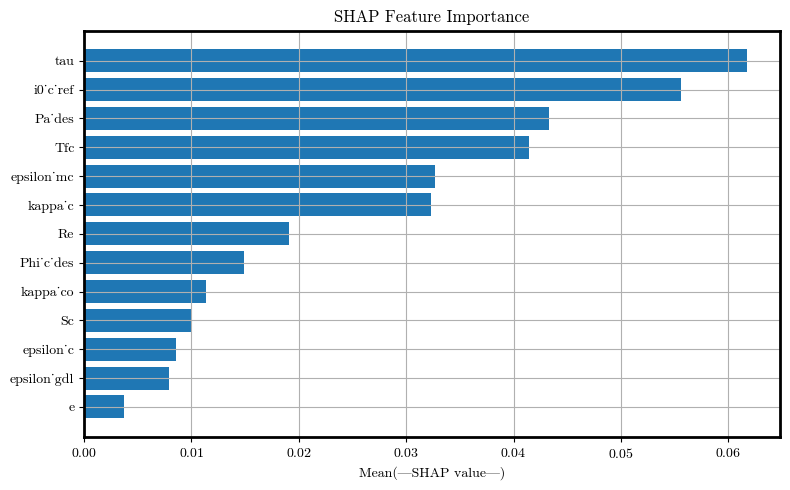

In [81]:
for seed in [42, 1, 7, 101]:
    print("Using seed", seed)
    shap_df = compute_shap_importance(model_ohmic, valid_data, region_name="ohmic", input_cols=INPUT_COLUMNS, sample_frac=0.3, random_state=seed)
    print(shap_df.head(6))
    plot_shap_bar(shap_df)

#### Why R² Might Be Limited

While our surrogate model is relatively stable across folds, the $R^2$ scores are modest (around 0.66), which suggests that there's still a good amount of variance in the AUC that the model cannot explain. There are a few possible reasons for this:

1. **The AUC target is inherently noisy**  
   We're predicting a discrete integral over a portion of a nonlinear voltage curve. Even small fluctuations or numerical artifacts in the AlphaPEM outputs can introduce noise that isn't captured by our 13 input features. So some variation in the AUC may not be explainable using the available inputs.

2. **Some relevant parameters might be missing**  
   The SHAP rankings show that only a few parameters have strong influence. That could mean that some inputs (possibly physical or operational) that do impact the voltage drop in this region are being held constant in our dataset. If that's the case, the model could be trying to explain behavior with incomplete information.

These limitations suggest that while the surrogate might be good enough for approximate sensitivity analysis, its precision is ultimately bounded by the data and model expressiveness.

## Sobol Analysis on Surrogate

To estimate global sensitivities, we run first-order Sobol analysis on the trained surrogate model (`model_ohmic`). This allows us to approximate the impact of each input parameter on the predicted AUC in the ohmic region, without running expensive AlphaPEM simulations.

We vary the sample size `N` to study the stability of the index estimates. For each setting, we:

1. Generate Saltelli samples
2. Predict AUC using the surrogate
3. Compute Sobol first-order indices using SALib
4. Check whether the indices sum to ~1, which indicates consistency

#### Sobol Sensitivity Analysis: Theory Recap

Recall that Sobol indices decompose output variance among input parameters and their interactions:

- **First-order index (S₁)** measures the fraction of variance due to an input’s individual effect.
- **Second-order indices (S₂)** capture pairwise interaction contributions.
- **Total-order index (S_T)** includes both main and interaction effects.

When input variables are independent:

- $\sum S₁ + \sum S₂ + \dots = 1$
- $\sum S_T \geq 1$ (since interactions contribute multiple times)

If the model is additive (no interactions), then $\sum S₁ = 1$ and $\sum S_T = 1$.

In our non‑additive surrogate, we expect:
- **$\sum S₁ < 1$** (since there are interactions)
- **S₁ + S₂ ≈ 1** (if we include second-order effects)
- **$\sum S_T > 1$** (because interactions are counted in multiple total effects)


#### Sobol Experiment and Index Checks

When running the analysis:

- If `calc_second_order=True`, we compute and check that $S₁ + S₂ ≈ 1$.
- We always report both **S₁** and **S_T** per feature.
- If the sums diverge, we show warnings so we can assess whether the surrogate is capturing variance properly.


In [55]:
def run_sobol_analysis(
    model,
    param_ranges,
    input_cols,
    N_list,
    calc_second_order=False,
    verbose=True
):
    """
    Run Sobol sensitivity analysis using a trained surrogate model.

    Parameters
    ----------
    model : fitted surrogate model
    param_ranges : dict
        Mapping of input name → [min, max]
    input_cols : list of str
        Ordered list of input feature names
    N_list : list of int
        List of base sample sizes N for Saltelli
    calc_second_order : bool
        Whether to compute 2nd-order interactions
    verbose : bool
        Whether to print progress messages

    Returns
    -------
    results : dict
        N → DataFrame with Sobol indices ('feature', 'S1', 'S1_conf', 'ST', 'ST_conf', 'S2_total' if applicable)
    """
    from SALib.sample import sobol as sobol_sampler
    from SALib.analyze import sobol as sobol_analyzer
    import warnings

    results = {}

    problem = {
        "num_vars": len(input_cols),
        "names": input_cols,
        "bounds": [param_ranges[k] for k in input_cols]
    }

    for N in N_list:
        if verbose:
            print(f"\n[INFO] Sobol analysis with N={N} (second-order: {calc_second_order})")

        # Generate samples
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            X_sobol = sobol_sampler.sample(problem, N, calc_second_order=calc_second_order)
        if verbose:
            print(f"[INFO] Generated {len(X_sobol)} samples.")

        # Predict with surrogate
        df_X = pd.DataFrame(X_sobol, columns=input_cols)
        y_pred = model.predict(df_X)
        if verbose:
            print(f"[INFO] Predicted model outputs.")

        # Analyze
        Si = sobol_analyzer.analyze(
            problem,
            y_pred,
            calc_second_order=calc_second_order,
            print_to_console=False
        )

        data = {
            "feature": input_cols,
            "S1": Si["S1"],
            "S1_conf": Si["S1_conf"],
            "ST": Si["ST"],
            "ST_conf": Si["ST_conf"]
        }

        # Track individual S2 contributions
        if calc_second_order:
            s2_matrix = Si["S2"]
            s2_totals = np.nansum(s2_matrix, axis=1)  # For feature-level totals (over all interactions)
            s2_sum = np.nansum(np.triu(s2_matrix, k=1))  # Correct total sum of unique pairwise effects
            data["S2_total"] = s2_totals
        else:
            s2_sum = 0.0

        result_df = pd.DataFrame(data).sort_values("ST", ascending=False).reset_index(drop=True)

        # Summarize variance decomposition
        s1_sum = np.nansum(Si["S1"])
        st_sum = np.nansum(Si["ST"])
        s1_s2_sum = s1_sum + s2_sum

        if verbose:
            print(f"[INFO] Sum S1 = {s1_sum:.4f}")
            if calc_second_order:
                print(f"[INFO] Sum S2 (unique pairs) = {s2_sum:.4f}")
                print(f"[INFO] Sum S1 + S2 = {s1_s2_sum:.4f} (should be ≈ 1)")
            print(f"[INFO] Sum ST = {st_sum:.4f} (may be > 1 due to overlapping effects)")

            if calc_second_order and not np.isclose(s1_s2_sum, 1.0, atol=0.1):
                print("[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.")

        results[N] = result_df

    return results


#### Define Parameter Ranges
These must match the model inputs and their ranges

In [56]:
PARAMETER_RANGES = {
    'Tfc': [333, 363],
    'Pa_des': [130000.0, 300000.0],
    'Sc': [1.1, 3.0],
    'Phi_c_des': [0.1, 0.7],
    'epsilon_gdl': [0.55, 0.8],
    'tau': [1.0, 4.0],
    'epsilon_mc': [0.15, 0.4],
    'epsilon_c': [0.15, 0.3],
    'e': [3, 5],  # Note: treat discrete param as continuous (approximate)
    'Re': [5e-7, 5e-6],
    'i0_c_ref': [0.001, 80],
    'kappa_co': [15, 40],
    'kappa_c': [0, 2.5],
}

In [ ]:
N_list = [256, 512, 1024, 2048, 4096]  # Increase for more resolution
sobol_results_ohmic = run_sobol_analysis(
    model=model_ohmic,
    param_ranges=PARAMETER_RANGES,
    input_cols=INPUT_COLUMNS,
    N_list=N_list,
    calc_second_order=True  # enables 2nd-order interaction terms
)


[INFO] Sobol analysis with N=256 (second-order: True)
[INFO] Generated 7168 samples.
[INFO] Predicted model outputs.


c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Sum S1 = 0.8664
[INFO] Sum S2 (unique pairs) = -0.6298
[INFO] Sum S1 + S2 = 0.2366 (should be ≈ 1)
[INFO] Sum ST = 1.3212 (may be > 1 due to overlapping effects)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.

[INFO] Sobol analysis with N=512 (second-order: True)
[INFO] Generated 14336 samples.
[INFO] Predicted model outputs.


c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Sum S1 = 0.8114
[INFO] Sum S2 (unique pairs) = 0.3245
[INFO] Sum S1 + S2 = 1.1359 (should be ≈ 1)
[INFO] Sum ST = 1.3801 (may be > 1 due to overlapping effects)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.

[INFO] Sobol analysis with N=1024 (second-order: True)
[INFO] Generated 28672 samples.
[INFO] Predicted model outputs.


...

[INFO] Sum S1 = 0.5833
[INFO] Sum S2 (unique pairs) = 0.3597
[INFO] Sum S1 + S2 = 0.9430 (should be ≈ 1)
[INFO] Sum ST = 1.4792 (may be > 1 due to overlapping effects)

[INFO] Sobol analysis with N=2048 (second-order: True)
[INFO] Generated 57344 samples.
[INFO] Predicted model outputs.


c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Sum S1 = 0.7015
[INFO] Sum S2 (unique pairs) = 0.0832
[INFO] Sum S1 + S2 = 0.7847 (should be ≈ 1)
[INFO] Sum ST = 1.5255 (may be > 1 due to overlapping effects)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.

[INFO] Sobol analysis with N=4096 (second-order: True)
[INFO] Generated 114688 samples.
[INFO] Predicted model outputs.


c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Sum S1 = 0.6726
[INFO] Sum S2 (unique pairs) = 0.2698
[INFO] Sum S1 + S2 = 0.9424 (should be ≈ 1)
[INFO] Sum ST = 1.4870 (may be > 1 due to overlapping effects)


In [ ]:
for N, df in sobol_results_ohmic.items():
    print(f"\n--- Sobol Results (N = {N}) ---")
    print(df.head(13))


--- Sobol Results (N = 256) ---
        feature        S1   S1_conf        ST   ST_conf  S2_total
0           tau  0.216382  0.112770  0.342394  0.089289 -0.206093
1      i0_c_ref  0.239865  0.085027  0.251575  0.072004  0.108638
2        Pa_des  0.104290  0.071981  0.174169  0.065510 -0.010430
3    epsilon_mc  0.108753  0.073073  0.167916  0.048674 -0.429349
4           Tfc  0.095176  0.057155  0.112869  0.033266 -0.200908
5       kappa_c  0.042921  0.054503  0.079312  0.019689  0.000000
6     Phi_c_des -0.002747  0.040168  0.042648  0.015744  0.052180
7            Re  0.040057  0.038687  0.041969  0.015951 -0.083624
8      kappa_co  0.004095  0.027724  0.039742  0.024142 -0.030558
9            Sc  0.011963  0.021096  0.026671  0.011881 -0.015870
10    epsilon_c  0.012663  0.033745  0.023631  0.010043  0.007312
11  epsilon_gdl -0.010918  0.029024  0.015993  0.005996  0.186923
12            e  0.003893  0.010071  0.002318  0.001873 -0.007987

--- Sobol Results (N = 512) ---
        fe

In [59]:
def plot_sobol_ranking(sobol_results, top_n=10):
    for N, df in sobol_results.items():
        plt.figure(figsize=(8, 4))
        top = df.head(top_n)
        plt.barh(top["feature"][::-1], top["S1"][::-1])
        plt.title(f"Top {top_n} First-Order Sobol Indices (N={N})")
        plt.xlabel("S1")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

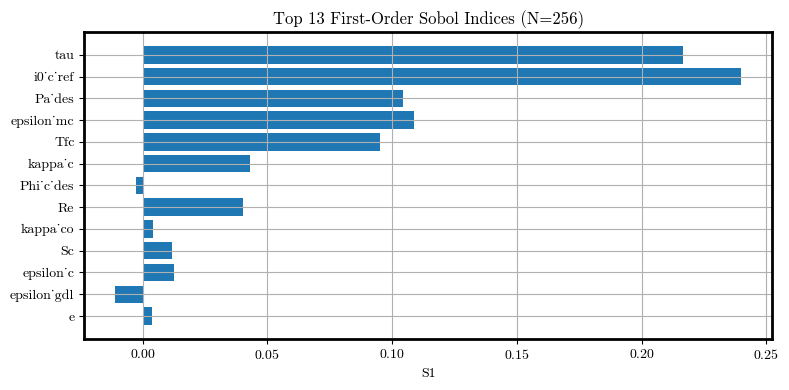

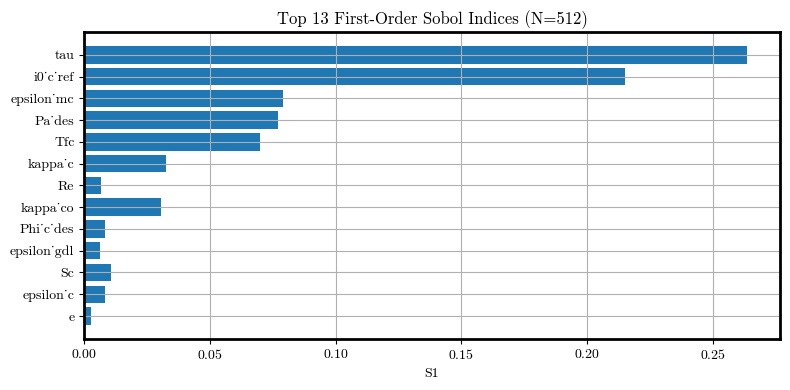

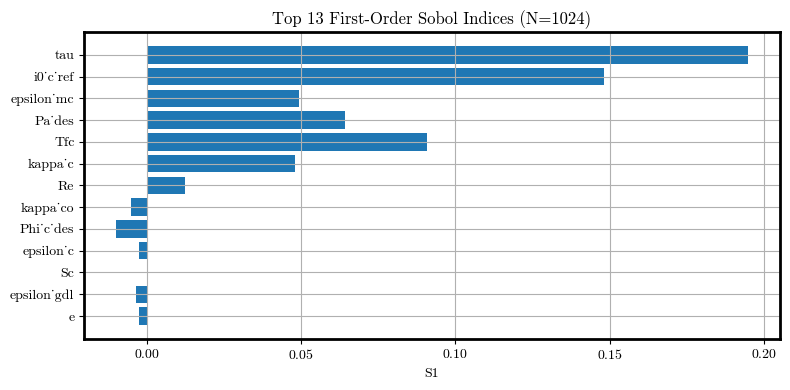

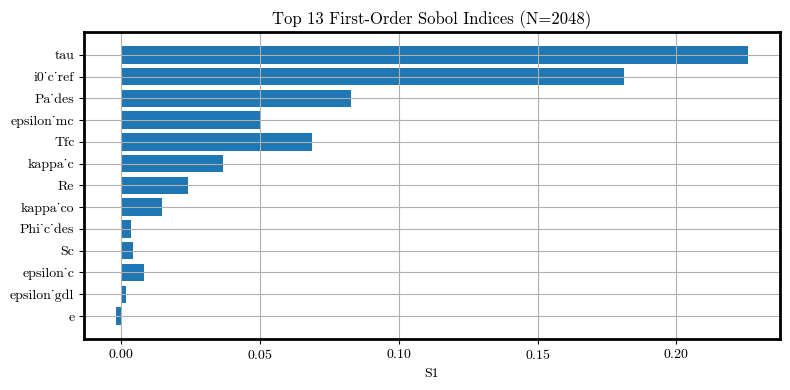

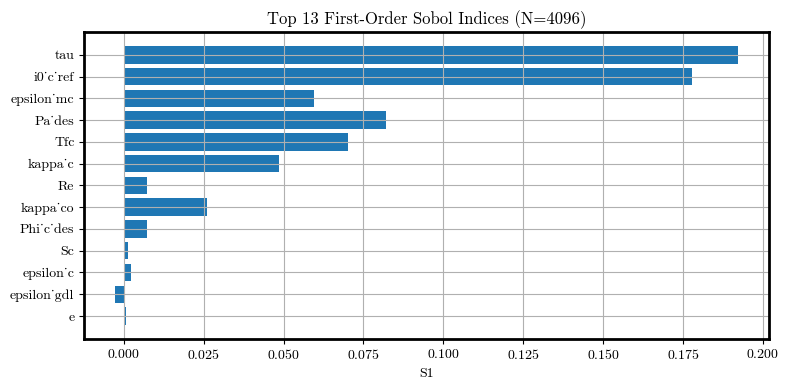

In [ ]:
plot_sobol_ranking(sobol_results_ohmic, top_n = 13)

In [63]:
def plot_sobol_index_convergence(sobol_results, index_type="ST", top_k=8, title=None, log_x=True):
    """
    Plot how each feature's Sobol index (S1 or ST) changes as sample size N increases.

    Parameters
    ----------
    sobol_results : dict
        Output from run_sobol_analysis(). Maps N → DataFrame with columns ['feature', ..., 'S1', 'ST'].
    index_type : str
        Which index to plot: "S1" for first-order or "ST" for total-order.
    top_k : int
        Number of top features to show based on the highest N.
    title : str or None
        Custom plot title. If None, defaults to f"{index_type} Index Convergence".
    log_x : bool
        Use log scale on the x-axis (sample size N).
    """
    assert index_type in ["S1", "ST"], "index_type must be 'S1' or 'ST'"

    # Pick top-k features at highest N
    max_N = max(sobol_results)
    top_features = sobol_results[max_N].sort_values(index_type, ascending=False)["feature"].head(top_k).tolist()

    # Gather index values across N
    N_vals = sorted(sobol_results.keys())
    data = {f: [] for f in top_features}

    for N in N_vals:
        df = sobol_results[N].set_index("feature")
        for f in top_features:
            v = df.loc[f, index_type] if f in df.index else np.nan
            data[f].append(v)

    # Plot
    plt.figure(figsize=(10, 6))
    for f in top_features:
        plt.plot(N_vals, data[f], marker="o", label=f)

    plt.ylabel(f"{index_type} Sobol Index")
    plt.xlabel("Sample Size N")
    plt.ylim(0, 1.05)
    if title is None:
        title = f"{index_type} Index Convergence"
    plt.title(title)
    if log_x:
        plt.xscale("log")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend(loc="upper right", bbox_to_anchor=(1.18, 1.0))
    plt.tight_layout()
    plt.show()


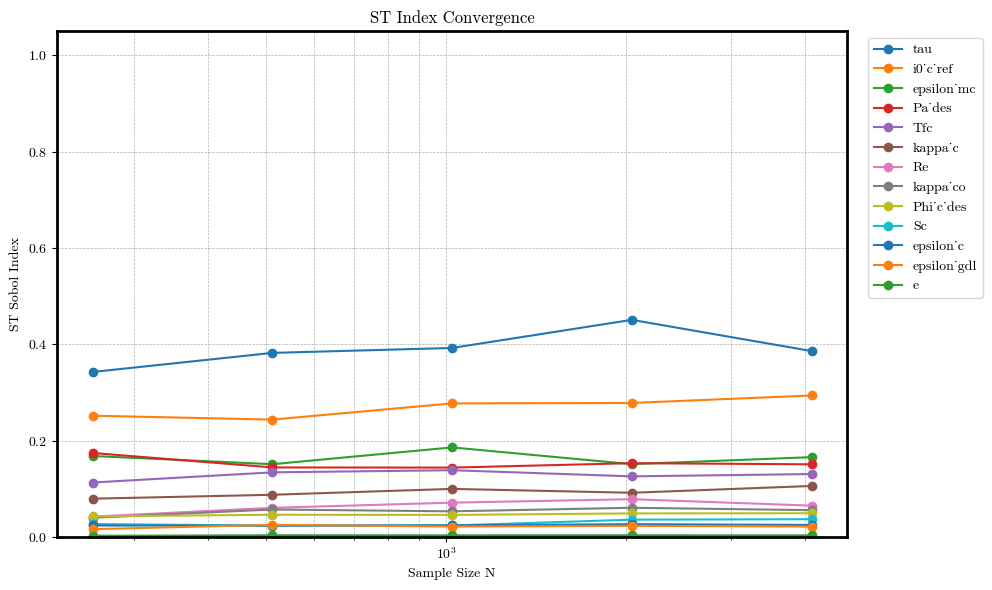

In [ ]:
plot_sobol_index_convergence(sobol_results_ohmic, top_k=13, index_type="ST")

## Processing: Activation region

This region covers low current densities (ifc < 0.4). Let's train the surrogate and evaluate everything.

In [82]:
model_activation, metrics_activation = train_auc_model_for_region(
    valid_data, region_name="activation", input_cols=INPUT_COLUMNS
)

print("Metrics for the Activation region")
print(metrics_activation)

[INFO] Starting nested CV for region: 'activation' in range (0.0, 0.4)
[INFO] Identified 31 current density columns and 31 voltage columns.
[INFO] Computing AUC target for region: activation
[INFO] Dropped 0 samples with no valid AUC in this region. Remaining: 27708
[INFO] Input shape: (27708, 13). Target shape: (27708,)
[INFO] Defined hyperparameter grid with 72 combinations

[INFO] Starting outer fold 1/5
[INFO] Performing inner grid search (3-fold CV)...
[INFO] Best hyperparameters for fold 1: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 700, 'subsample': 0.8}
[INFO] Fold 1 results — MAE=0.0064, R²=0.7676, RMSE=0.0003

[INFO] Starting outer fold 2/5
[INFO] Performing inner grid search (3-fold CV)...
[INFO] Best hyperparameters for fold 2: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 700, 'subsample': 0.8}
[INFO] Fold 2 results — MAE=0.0063, R²=0.7687, RMSE=0.0003

[INFO] Starting outer fold 3/5
[INFO] Performing

In [83]:
# SHAP analysis on full data
shap_df_activation = compute_shap_importance(
    model=model_activation,
    df=valid_data,
    region_name="activation",
    input_cols=INPUT_COLUMNS,
    sample_frac=1
)

shap_df_activation

[INFO] Using full dataset (27708 rows) for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] Aggregating mean absolute SHAP values per feature...


,feature,mean_abs_shap
10,i0_c_ref,0.013675
12,kappa_c,0.009987
0,Tfc,0.006973
5,tau,0.005272
1,Pa_des,0.004610
11,kappa_co,0.003333
6,epsilon_mc,0.002850
2,Sc,0.001834
9,Re,0.001307
3,Phi_c_des,0.000995


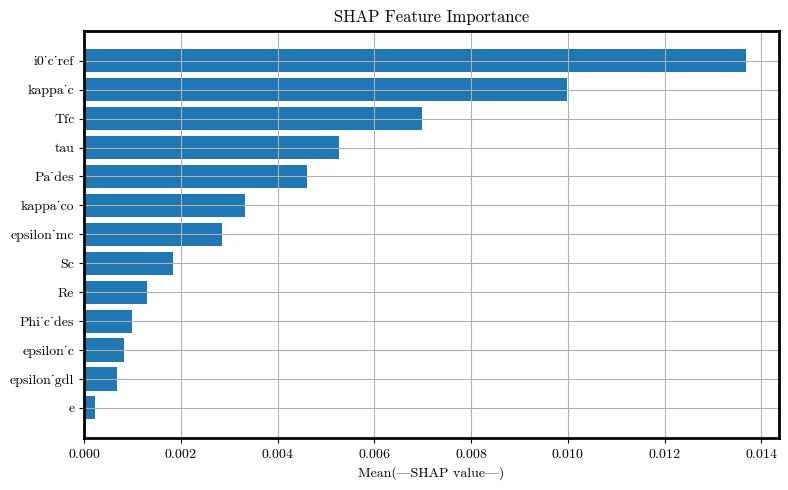

In [84]:
plot_shap_bar(shap_df_activation)

In [85]:
# Save model, metrics, SHAP ranking
save_model_results(
    model=model_activation,
    region_name="activation",
    input_cols=INPUT_COLUMNS,
    df=valid_data,
    cv_scores=metrics_activation,
    shap_df=shap_df_activation
)

[INFO] Saved model to ../results/xgboost\xgb_activation_model.pkl
[INFO] Saved metrics to ../results/xgboost\xgb_activation_metrics.json
[INFO] Saved SHAP ranking to ../results/xgboost\xgb_activation_shap.csv


In [86]:
# Sobol: test multiple sample sizes
N_list = [256, 512, 1024, 2048, 4096]
sobol_results_activation = run_sobol_analysis(
    model=model_activation,
    param_ranges=PARAMETER_RANGES,
    input_cols=INPUT_COLUMNS,
    N_list=N_list,
    calc_second_order=True
)

# Print Sobol outputs
for N, df in sobol_results_activation.items():
    print(f"\n--- Sobol Results (Activation, N = {N}) ---")
    print(df.head(13))


[INFO] Sobol analysis with N=256 (second-order: True)
[INFO] Generated 7168 samples.
[INFO] Predicted model outputs.


c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Sum S1 = 0.8140
[INFO] Sum S2 (unique pairs) = -0.5512
[INFO] Sum S1 + S2 = 0.2628 (should be ≈ 1)
[INFO] Sum ST = 1.2281 (may be > 1 due to overlapping effects)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.

[INFO] Sobol analysis with N=512 (second-order: True)
[INFO] Generated 14336 samples.
[INFO] Predicted model outputs.


c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Sum S1 = 0.8919
[INFO] Sum S2 (unique pairs) = 0.0973
[INFO] Sum S1 + S2 = 0.9892 (should be ≈ 1)
[INFO] Sum ST = 1.1773 (may be > 1 due to overlapping effects)

[INFO] Sobol analysis with N=1024 (second-order: True)
[INFO] Generated 28672 samples.
[INFO] Predicted model outputs.


...

[INFO] Sum S1 = 0.8440
[INFO] Sum S2 (unique pairs) = -0.0420
[INFO] Sum S1 + S2 = 0.8019 (should be ≈ 1)
[INFO] Sum ST = 1.1597 (may be > 1 due to overlapping effects)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.

[INFO] Sobol analysis with N=2048 (second-order: True)
[INFO] Generated 57344 samples.
[INFO] Predicted model outputs.


c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Sum S1 = 0.9014
[INFO] Sum S2 (unique pairs) = 0.2548
[INFO] Sum S1 + S2 = 1.1562 (should be ≈ 1)
[INFO] Sum ST = 1.2259 (may be > 1 due to overlapping effects)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.

[INFO] Sobol analysis with N=4096 (second-order: True)
[INFO] Generated 114688 samples.
[INFO] Predicted model outputs.


c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Sum S1 = 0.8706
[INFO] Sum S2 (unique pairs) = 0.0702
[INFO] Sum S1 + S2 = 0.9409 (should be ≈ 1)
[INFO] Sum ST = 1.1835 (may be > 1 due to overlapping effects)

--- Sobol Results (Activation, N = 256) ---
        feature        S1   S1_conf        ST   ST_conf  S2_total
0      i0_c_ref  0.435613  0.155523  0.558979  0.122106  0.132292
1       kappa_c  0.125504  0.069633  0.229233  0.055568  0.000000
2           tau  0.084709  0.053413  0.126694  0.047239 -0.333514
3           Tfc  0.070493  0.061569  0.106309  0.025718 -0.082303
4        Pa_des  0.058435  0.039579  0.080654  0.024826 -0.295820
5    epsilon_mc -0.004211  0.036738  0.048251  0.019425  0.091274
6      kappa_co  0.030589  0.027671  0.029954  0.008665  0.007174
7            Sc -0.006485  0.024448  0.017149  0.006306 -0.063026
8            Re  0.010614  0.019746  0.009742  0.003121 -0.031879
9     Phi_c_des -0.005262  0.012715  0.009077  0.003570  0.053227
10    epsilon_c  0.014550  0.021349  0.007178  0.003137 -0.04

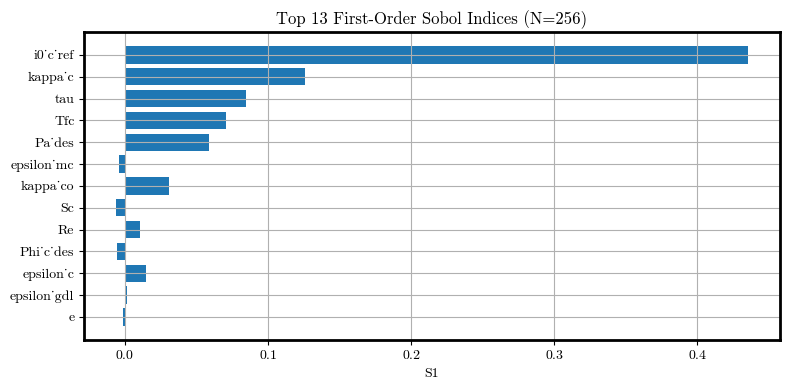

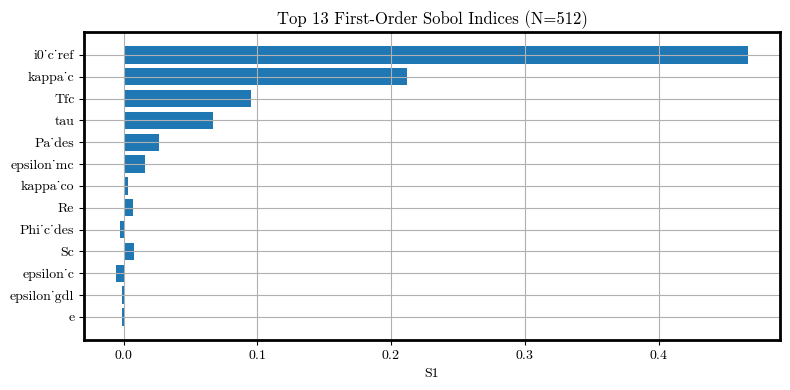

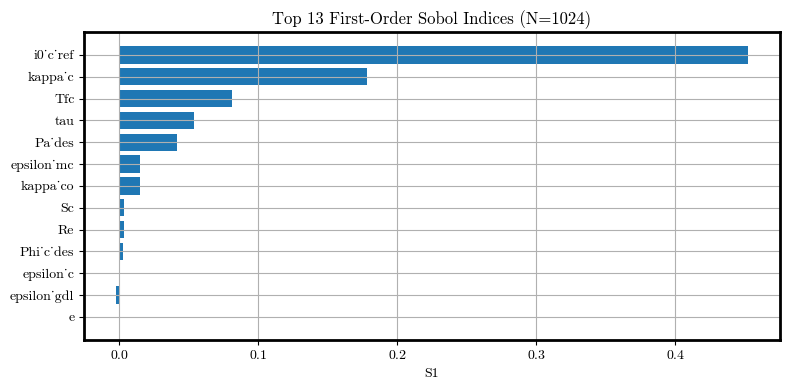

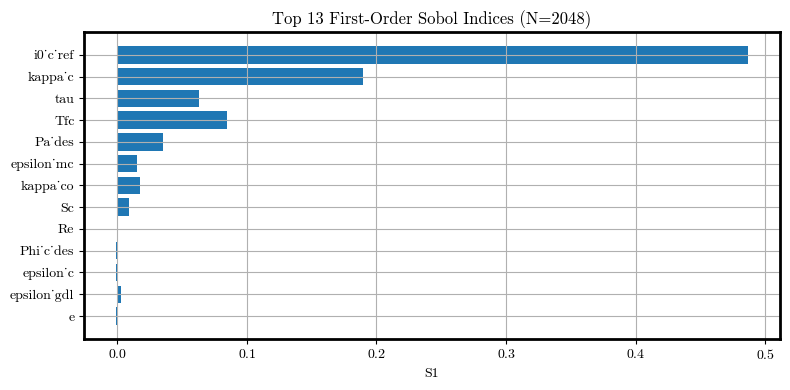

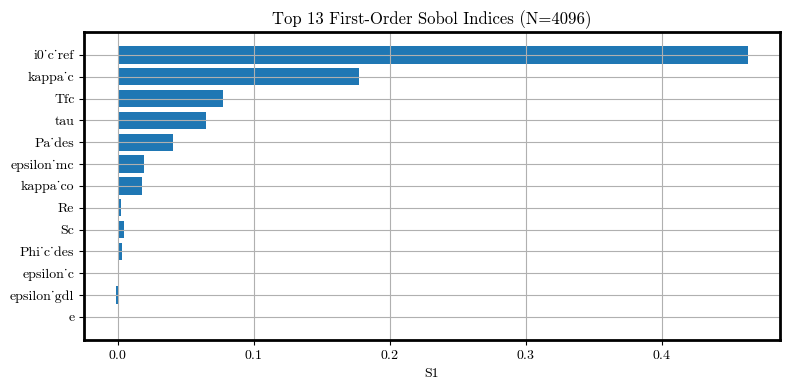

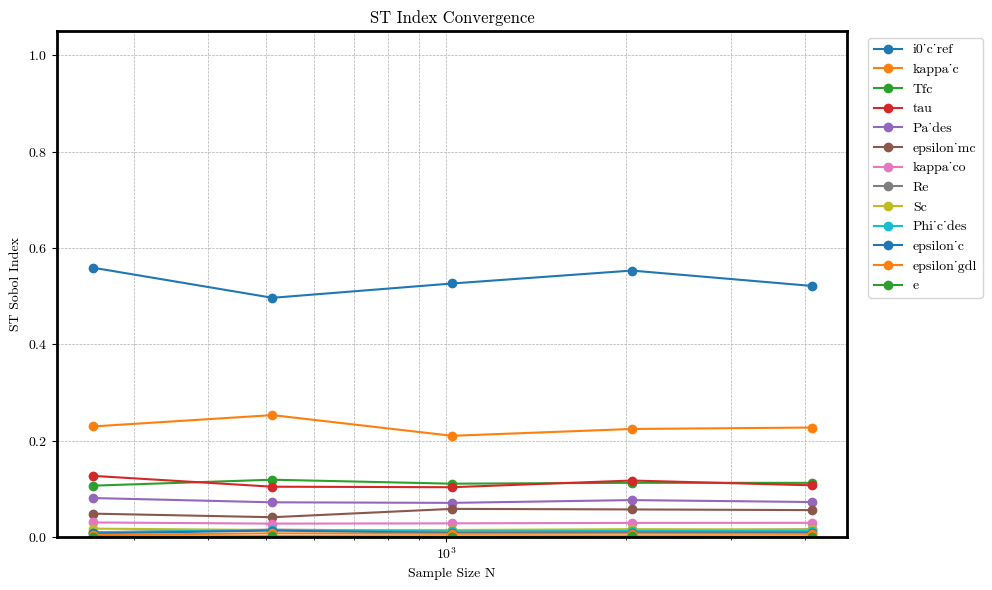

In [87]:
# Show and save Sobol + SHAP results
plot_sobol_ranking(sobol_results_activation, top_n=13)
plot_sobol_index_convergence(sobol_results_activation, top_k=13, index_type="ST")

## Processing: Mass Transport region
This covers the high current density regime (ifc ≥ 1.6). Let's repeat everything for this region too.

In [88]:
model_mass, metrics_mass = train_auc_model_for_region(
    valid_data, region_name="mass_transport", input_cols=INPUT_COLUMNS
)

print("Metrics for the Mass Transport region")
print(metrics_mass)

[INFO] Starting nested CV for region: 'mass_transport' in range (1.6, inf)
[INFO] Identified 31 current density columns and 31 voltage columns.
[INFO] Computing AUC target for region: mass_transport
[INFO] Dropped 0 samples with no valid AUC in this region. Remaining: 27708
[INFO] Input shape: (27708, 13). Target shape: (27708,)
[INFO] Defined hyperparameter grid with 72 combinations

[INFO] Starting outer fold 1/5
[INFO] Performing inner grid search (3-fold CV)...
[INFO] Best hyperparameters for fold 1: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 700, 'subsample': 0.8}
[INFO] Fold 1 results — MAE=0.1308, R²=0.6346, RMSE=0.1356

[INFO] Starting outer fold 2/5
[INFO] Performing inner grid search (3-fold CV)...
[INFO] Best hyperparameters for fold 2: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 700, 'subsample': 0.8}
[INFO] Fold 2 results — MAE=0.1312, R²=0.6262, RMSE=0.1459

[INFO] Starting outer fold 3/5
[INFO] Pe

In [89]:
# SHAP values on full data
shap_df_mass = compute_shap_importance(
    model=model_mass,
    df=valid_data,
    region_name="mass_transport",
    input_cols=INPUT_COLUMNS,
    sample_frac=1
)

shap_df_mass

[INFO] Using full dataset (27708 rows) for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] Aggregating mean absolute SHAP values per feature...


,feature,mean_abs_shap
5,tau,0.137299
6,epsilon_mc,0.078830
10,i0_c_ref,0.075206
1,Pa_des,0.072007
0,Tfc,0.062405
9,Re,0.051208
12,kappa_c,0.030824
3,Phi_c_des,0.027489
11,kappa_co,0.024947
2,Sc,0.022436


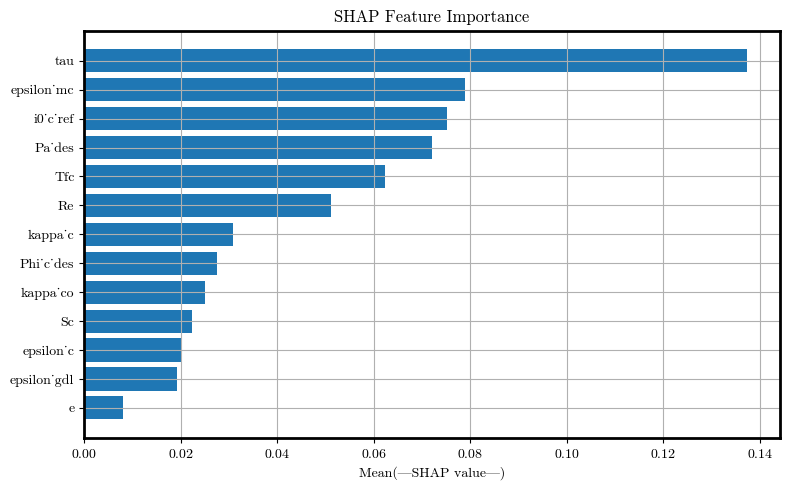

In [90]:
plot_shap_bar(shap_df_mass)

In [91]:
# Save model and SHAP outputs
save_model_results(
    model=model_mass,
    region_name="mass_transport",
    input_cols=INPUT_COLUMNS,
    df=valid_data,
    cv_scores=metrics_mass,
    shap_df=shap_df_mass
)

[INFO] Saved model to ../results/xgboost\xgb_mass_transport_model.pkl
[INFO] Saved metrics to ../results/xgboost\xgb_mass_transport_metrics.json
[INFO] Saved SHAP ranking to ../results/xgboost\xgb_mass_transport_shap.csv


In [92]:
# Run Sobol analysis
N_list = [256, 512, 1024, 2048, 4096]
sobol_results_mass = run_sobol_analysis(
    model=model_mass,
    param_ranges=PARAMETER_RANGES,
    input_cols=INPUT_COLUMNS,
    N_list=N_list,
    calc_second_order=True
)

# Print Sobol tables
for N, df in sobol_results_mass.items():
    print(f"\n--- Sobol Results (Mass Transport, N = {N}) ---")
    print(df.head(13))


[INFO] Sobol analysis with N=256 (second-order: True)
[INFO] Generated 7168 samples.
[INFO] Predicted model outputs.


c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Sum S1 = 0.5152
[INFO] Sum S2 (unique pairs) = 0.0804
[INFO] Sum S1 + S2 = 0.5956 (should be ≈ 1)
[INFO] Sum ST = 1.4876 (may be > 1 due to overlapping effects)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.

[INFO] Sobol analysis with N=512 (second-order: True)
[INFO] Generated 14336 samples.
[INFO] Predicted model outputs.


c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Sum S1 = 0.8567
[INFO] Sum S2 (unique pairs) = 0.8649
[INFO] Sum S1 + S2 = 1.7216 (should be ≈ 1)
[INFO] Sum ST = 1.6723 (may be > 1 due to overlapping effects)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.

[INFO] Sobol analysis with N=1024 (second-order: True)
[INFO] Generated 28672 samples.
[INFO] Predicted model outputs.


...

[INFO] Sum S1 = 0.6701
[INFO] Sum S2 (unique pairs) = -0.0195
[INFO] Sum S1 + S2 = 0.6506 (should be ≈ 1)
[INFO] Sum ST = 1.6708 (may be > 1 due to overlapping effects)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.

[INFO] Sobol analysis with N=2048 (second-order: True)
[INFO] Generated 57344 samples.
[INFO] Predicted model outputs.


c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Sum S1 = 0.6095
[INFO] Sum S2 (unique pairs) = 0.1727
[INFO] Sum S1 + S2 = 0.7822 (should be ≈ 1)
[INFO] Sum ST = 1.5629 (may be > 1 due to overlapping effects)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.

[INFO] Sobol analysis with N=4096 (second-order: True)
[INFO] Generated 114688 samples.
[INFO] Predicted model outputs.


c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Sum S1 = 0.6075
[INFO] Sum S2 (unique pairs) = 0.0465
[INFO] Sum S1 + S2 = 0.6540 (should be ≈ 1)
[INFO] Sum ST = 1.6056 (may be > 1 due to overlapping effects)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.

--- Sobol Results (Mass Transport, N = 256) ---
        feature        S1   S1_conf        ST   ST_conf  S2_total
0           tau  0.286748  0.122415  0.448796  0.119208 -0.379738
1    epsilon_mc  0.057985  0.075049  0.231072  0.119797 -0.289896
2      i0_c_ref  0.030530  0.060643  0.195664  0.077700  0.021005
3        Pa_des  0.077229  0.089107  0.137901  0.046109 -0.132584
4           Tfc  0.024227  0.054681  0.102564  0.035434  0.342198
5            Re  0.027273  0.047457  0.099571  0.059298  0.062017
6      kappa_co  0.008423  0.037118  0.061954  0.046944 -0.003617
7       kappa_c  0.008252  0.037766  0.059003  0.042885  0.000000
8     Phi_c_des  0.005582  0.050585  0.054176  0.026192  0.020986
9            Sc  0.021644  0.050100  0.039268 

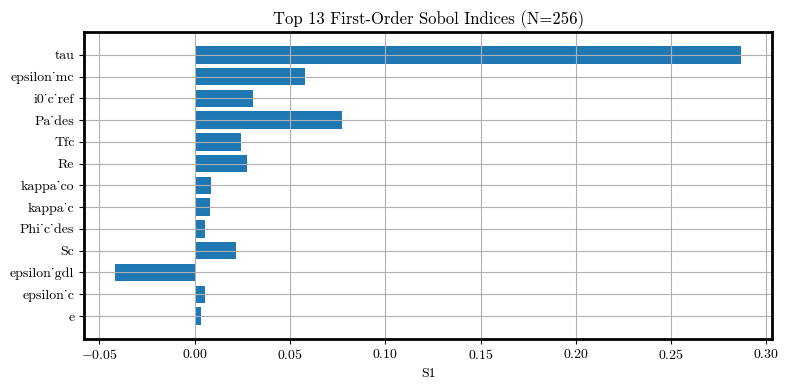

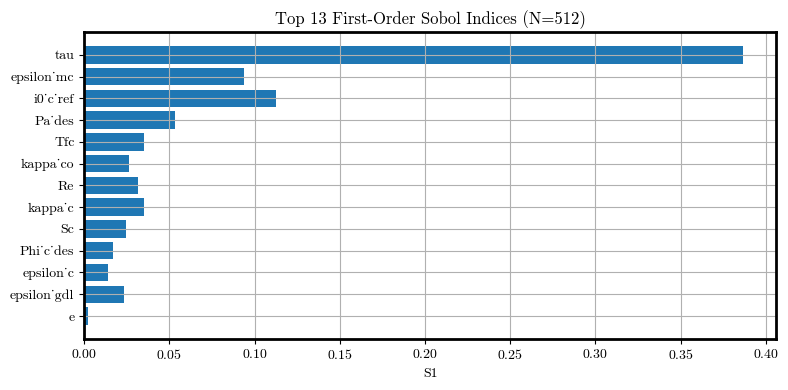

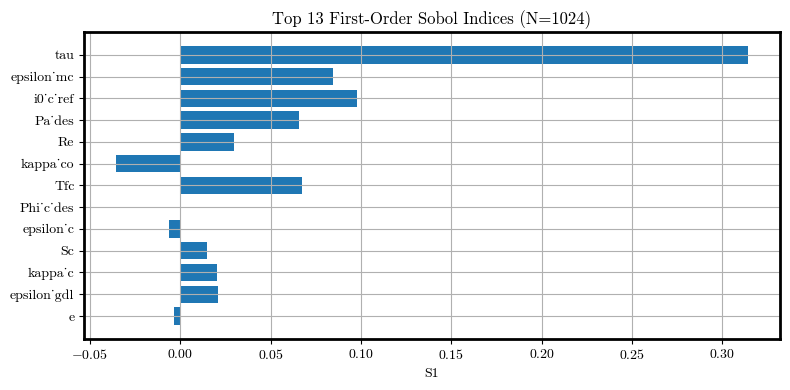

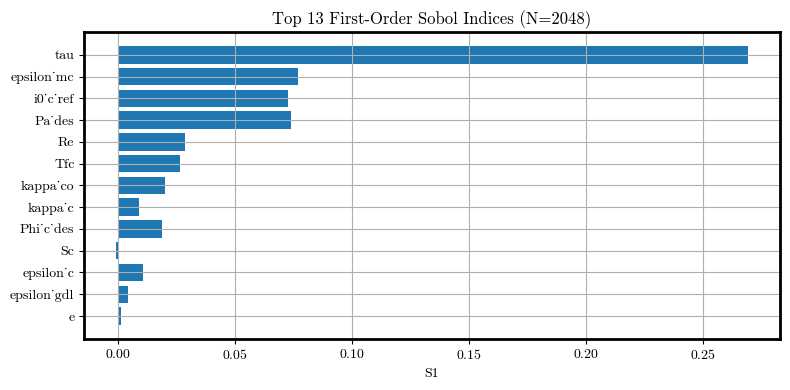

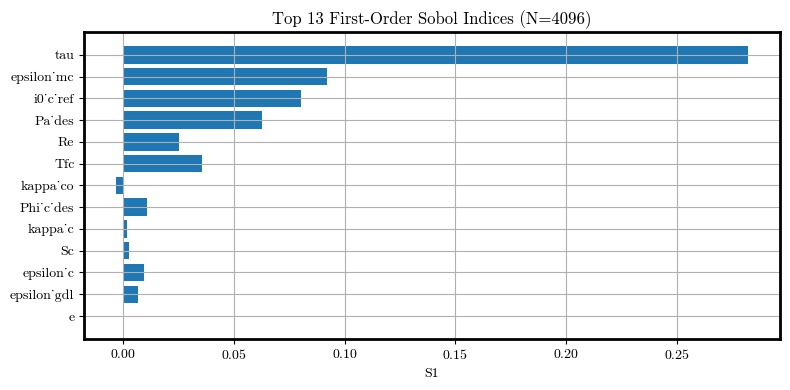

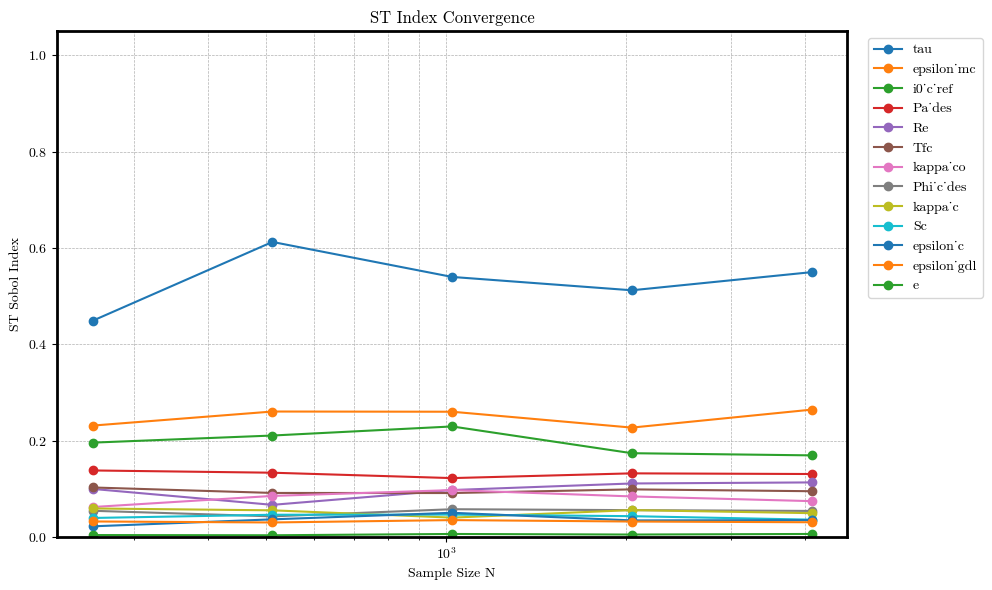

In [93]:
# Show and save visuals
plot_sobol_ranking(sobol_results_mass, top_n=13)
plot_sobol_index_convergence(sobol_results_mass, top_k=13, index_type="ST")